In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)


In [4]:
print("Dataset Shape:", X.shape)

print("\nFeatures:")
print(X.columns)

print("\nTarget Classes:", data.target_names)


Dataset Shape: (569, 30)

Features:
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

Target Classes: ['malignant' 'benign']


In [5]:
print("\nMissing Values:")
print(X.isnull().sum())



Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = Sequential()
model.add(Dense(
    30,
    input_shape=(30,),
    activation='relu'
))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


C:\Users\bathu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7747 - loss: 0.5898 - val_accuracy: 0.9011 - val_loss: 0.4221
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9423 - loss: 0.3453 - val_accuracy: 0.9231 - val_loss: 0.2722
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9478 - loss: 0.2194 - val_accuracy: 0.9231 - val_loss: 0.2008
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9670 - loss: 0.1524 - val_accuracy: 0.9231 - val_loss: 0.1602
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9808 - loss: 0.1124 - val_accuracy: 0.9341 - val_loss: 0.1407
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9780 - loss: 0.0913 - val_accuracy: 0.9451 - val_loss: 0.1277
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9835 - loss: 0.0771 - val_accuracy: 0.9451 - val_loss: 0.1221
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9835 - loss: 0.0674 - val_accuracy: 0.9560 - val

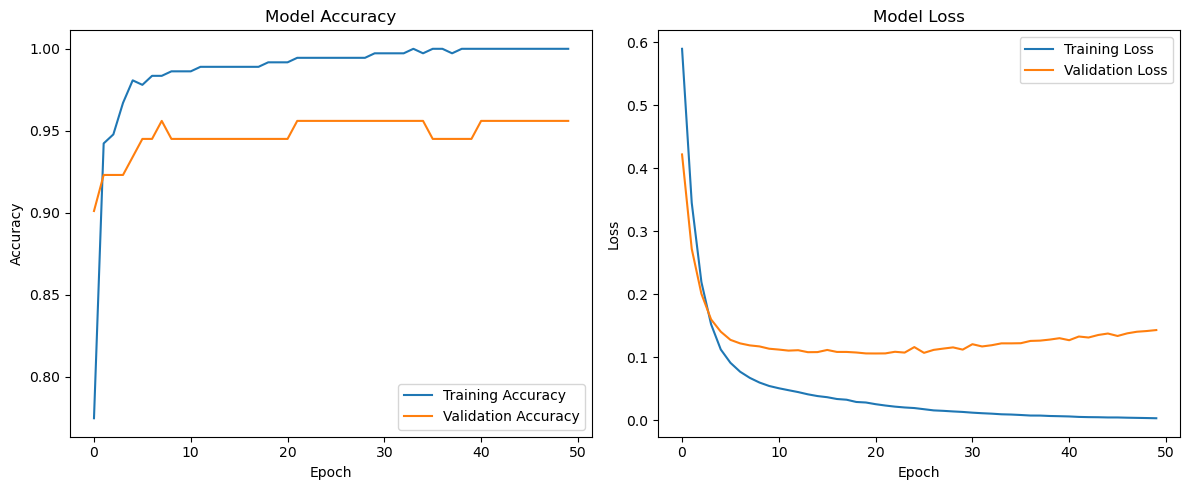

In [9]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Loss
plt.subplot(1, 2, 2)

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [10]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9649 - loss: 0.1148

Test Loss: 0.11483180522918701
Test Accuracy: 0.9649122953414917


In [11]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)
print(
    "\nAccuracy:",
    accuracy_score(y_test, y_pred)
)
print(
    "\nAccuracy:",
    accuracy_score(y_test, y_pred)
)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Accuracy: 0.9649122807017544

Accuracy: 0.9649122807017544


In [12]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[41  2]
 [ 2 69]]


In [13]:
print(
    "\nPrecision:",
    precision_score(y_test, y_pred)
)

print(
    "Recall:",
    recall_score(y_test, y_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred)
)



Precision: 0.971830985915493
Recall: 0.971830985915493
F1 Score: 0.971830985915493


In [14]:
new_sample = X_test[:5]

prediction = model.predict(new_sample)

print("\nPredictions for New Samples:")

print(
    (prediction > 0.5).astype(int)
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

Predictions for New Samples:
[[1]
 [0]
 [0]
 [1]
 [1]]


In [15]:
new_sample = X_test[:5]

prediction = model.predict(new_sample)

print("\nPredictions for New Samples:")

print(
    (prediction > 0.5).astype(int)
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

Predictions for New Samples:
[[1]
 [0]
 [0]
 [1]
 [1]]


In [16]:
model1 = Sequential([
    Dense(
        16,
        input_shape=(30,),
        activation='relu'
    ),
    Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model1.fit(
    X_train,
    y_train,
    epochs=30,
    verbose=0
)

print(
    "1 Hidden Layer Accuracy:",
    model1.evaluate(
        X_test,
        y_test,
        verbose=0
    )[1]
)


C:\Users\bathu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1 Hidden Layer Accuracy: 0.9824561476707458


In [17]:
model2 = Sequential([
    Dense(
        16,
        input_shape=(30,),
        activation='relu'
    ),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.fit(
    X_train,
    y_train,
    epochs=30,
    verbose=0
)

print(
    "2 Hidden Layers Accuracy:",
    model2.evaluate(
        X_test,
        y_test,
        verbose=0
    )[1]
)


C:\Users\bathu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2 Hidden Layers Accuracy: 0.9912280440330505


In [18]:
for n in [8, 16, 32]:

    model = Sequential([
        Dense(
            n,
            input_shape=(30,),
            activation='relu'
        ),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train,
        y_train,
        epochs=30,
        verbose=0
    )

    print(
        "Neurons",
        n,
        "Accuracy:",
        model.evaluate(
            X_test,
            y_test,
            verbose=0
        )[1]
    )


Neurons 8 Accuracy: 0.9912280440330505
Neurons 16 Accuracy: 0.9824561476707458
Neurons 32 Accuracy: 0.9736841917037964


In [19]:
for opt in ['adam', 'sgd']:

    model = Sequential([
        Dense(
            16,
            input_shape=(30,),
            activation='relu'
        ),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train,
        y_train,
        epochs=30,
        verbose=0
    )

    print(
        opt,
        "Accuracy:",
        model.evaluate(
            X_test,
            y_test,
            verbose=0
        )[1]
    )


adam Accuracy: 0.9824561476707458
sgd Accuracy: 0.9473684430122375


In [20]:
for act in ['relu', 'tanh', 'sigmoid']:

    model = Sequential([
        Dense(
            16,
            input_shape=(30,),
            activation=act
        ),
        Dense(16, activation=act),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train,
        y_train,
        epochs=30,
        verbose=0
    )

    print(
        act,
        "Activation Accuracy:",
        model.evaluate(
            X_test,
            y_test,
            verbose=0
        )[1]
    )


relu Activation Accuracy: 0.9824561476707458
tanh Activation Accuracy: 0.9736841917037964
sigmoid Activation Accuracy: 0.9824561476707458
